# 22DM015 Advanced Methods in NLP: Final Project
## Deceptive Opinion Spam Classification
### Barcelona School of Economics


### Dmitrii Kuptsov, Insaf Ibragimov, Sofia Pirogova

In [75]:
import random, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
except ImportError:
    DEVICE = "cpu"

print("device:", DEVICE)

device: mps


In [76]:
from sklearn.metrics import precision_score, recall_score

class Metrics:
    def __init__(self): self.results = {}

    def run(self, y_true, y_pred, name, average="macro"):
        self.results[name] = {
            "accuracy":  accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
            "recall":    recall_score(y_true, y_pred, average=average, zero_division=0),
            "f1":        f1_score(y_true, y_pred, average=average, zero_division=0),
        }
        print(f"{name}  →  F1={self.results[name]['f1']:.3f}  Acc={self.results[name]['accuracy']:.3f}")

    def table(self): return pd.DataFrame(self.results).T.round(4)

    def plot(self, title=""):
        self.table().mul(100).plot(kind="bar", figsize=(max(8, len(self.results)*1.5), 5), ylim=(0,105), rot=30)
        plt.title(title)
        plt.ylabel("%")
        plt.tight_layout()
        plt.show()

metrics = Metrics()

---
## Part 1. Setting Up the Problem

### 1a. Bibliography and State of the Art

The task is binary text classification: label an English hotel review as fake (written by a paid crowdworker who never stayed) or genuine (scraped from TripAdvisor). The dataset, [Ott et al. op_spam_v1.4](https://aclanthology.org/P11-1032/), has been a standard benchmark since [ACL 2011](https://aclanthology.org/P11-1032/). [NAACL 2013](https://aclanthology.org/N13-1053/) added negative reviews. [Papers with Code](https://paperswithcode.com/task/deceptive-opinion-spam) tracks current results.

**Current state of the art:**
| Model | Accuracy |
|---|---|
| SVM + n-grams + LIWC | ~90% (Ott et al. 2011) |
| BERT fine-tuned | ~91% ([arXiv:2010.15296](https://arxiv.org/abs/2010.15296)) |
| Human judges | 53–62% ([arXiv:2407.03545](https://arxiv.org/abs/2407.03545)) |

The headline is the 30 point gap between humans and models. The cues splitting fake from genuine are not legible to a reader, even one looking for them. We look closer at the data next. We expect that automated detection may help

### 1b. Exploring the Data

We load the corpus and look at how the two classes differ: length, sentiment polarity, data source, and vocabulary. The goal is simple. We want the signals separating fake from genuine before any modelling.

In [77]:
import pandas as pd

df_raw = pd.read_csv("deceptive-opinion.csv")
df_raw.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


Length, sentences and punctuation by class


n_words         n_sent        punct_per_word       
              mean median    mean median           mean median
deceptive                                                     
deceptive  146.636  125.0   9.178    8.0          0.104  0.100
truthful   150.914  130.0  10.586    9.0          0.122  0.115


Sentiment polarity x class


polarity,negative,positive
deceptive,,
deceptive,400,400
truthful,400,400



Data source x class


source,MTurk,TripAdvisor,Web
deceptive,,,
deceptive,800,0,0
truthful,0,400,400



Most frequent words by class
  truthful  : ['hotel', 'room', 'stay', 'great', 'chicago', 'staff', 'service', 'stayed', 'location', 'night']
  deceptive : ['hotel', 'room', 'chicago', 'stay', 'service', 'staff', 'rooms', 'like', 'stayed', 'great']


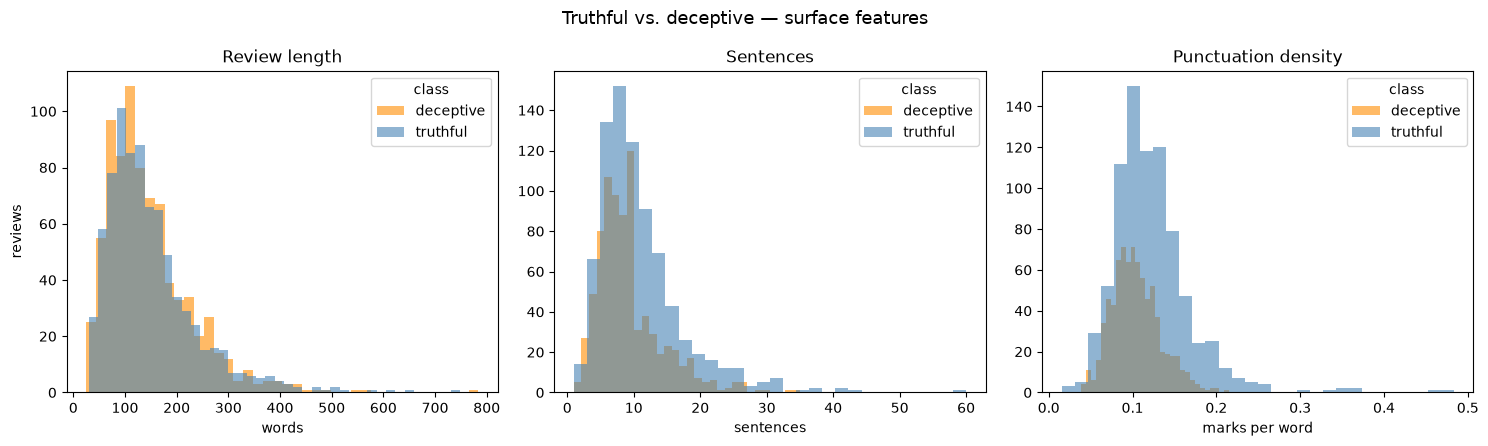

In [78]:
from spacy.lang.en.stop_words import STOP_WORDS

df_all = df_raw.copy()

TEXT_COL, LABEL_COL = "text", "deceptive"
label2id  = {"truthful": 0, "deceptive": 1}
id2label  = {0: "truthful", 1: "deceptive"}
NUM_LABELS = 2

df_all["label"]          = df_all[LABEL_COL].map(label2id)
df_all["n_words"]        = df_all[TEXT_COL].str.split().str.len()
df_all["n_sent"]         = df_all[TEXT_COL].str.count(r"[.!?]+").clip(lower=1)
df_all["punct_per_word"] = df_all[TEXT_COL].str.count(r"[.,!?;:]") / df_all["n_words"]

# length, sentences, punctuation by class
print("Length, sentences and punctuation by class")
display(df_all.groupby(LABEL_COL)[["n_words", "n_sent", "punct_per_word"]]
        .agg(["mean", "median"]).round(3))

print("\nSentiment polarity x class")
display(pd.crosstab(df_all[LABEL_COL], df_all["polarity"]))

print("\nData source x class")
display(pd.crosstab(df_all[LABEL_COL], df_all["source"]))

# most frequent words per class, ignoring standard english stopwords
print("\nMost frequent words by class")
for lbl in ["truthful", "deceptive"]:
    text  = " ".join(df_all[df_all[LABEL_COL] == lbl][TEXT_COL]).lower()
    words = [w for w in re.findall(r"[a-z]{4,}", text) if w not in STOP_WORDS]
    top   = [w for w, _ in Counter(words).most_common(10)]
    print(f"  {lbl:10s}: {top}")

# length / sentences / punctuation side by side
colors = {"truthful": "steelblue", "deceptive": "darkorange"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for lbl, grp in df_all.groupby(LABEL_COL):
    axes[0].hist(grp["n_words"],        bins=40, alpha=0.6, label=lbl, color=colors[lbl])
    axes[1].hist(grp["n_sent"],         bins=30, alpha=0.6, label=lbl, color=colors[lbl])
    axes[2].hist(grp["punct_per_word"], bins=30, alpha=0.6, label=lbl, color=colors[lbl])
axes[0].set(title="Review length",       xlabel="words", ylabel="reviews")
axes[1].set(title="Sentences",           xlabel="sentences")
axes[2].set(title="Punctuation density", xlabel="marks per word")
for ax in axes:
    ax.legend(title="class")
fig.suptitle("Truthful vs. deceptive — surface features", fontsize=13)
plt.tight_layout()
plt.show()

Average part-of-speech rates by class


,noun_rate,pron_rate,verb_rate,adj_rate
deceptive,,,,
deceptive,0.1864,0.1098,0.1059,0.0874
truthful,0.2081,0.0912,0.1000,0.0934


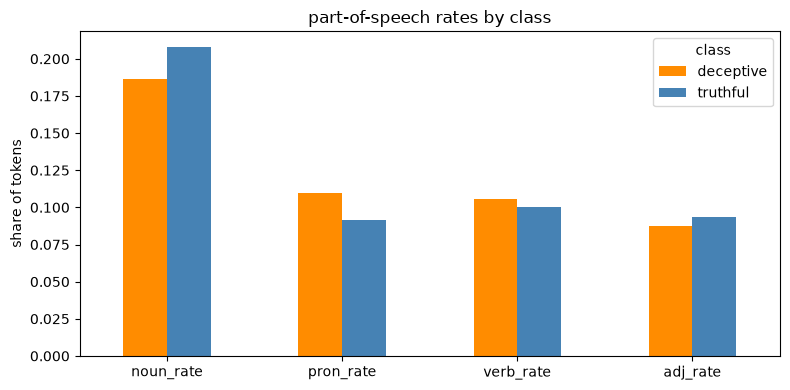

In [5]:
# part-of-speech share per review, reused as features in 1d
import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

noun_rate, pron_rate, verb_rate, adj_rate = [], [], [], []
for doc in nlp.pipe(df_all[TEXT_COL].astype(str)):
    words = [t for t in doc if t.is_alpha]
    n = max(len(words), 1)
    noun_rate.append(sum(t.pos_ == "NOUN" for t in words) / n)
    pron_rate.append(sum(t.pos_ == "PRON" for t in words) / n)
    verb_rate.append(sum(t.pos_ == "VERB" for t in words) / n)
    adj_rate.append( sum(t.pos_ == "ADJ"  for t in words) / n)

df_all["noun_rate"] = noun_rate
df_all["pron_rate"] = pron_rate
df_all["verb_rate"] = verb_rate
df_all["adj_rate"]  = adj_rate
POS_COLS = ["noun_rate", "pron_rate", "verb_rate", "adj_rate"]

print("Average part-of-speech rates by class")
pos_means = df_all.groupby(LABEL_COL)[POS_COLS].mean().round(4)
display(pos_means)

ax = pos_means.T.plot(kind="bar", figsize=(8, 4), rot=0, color=colors,
                      title="part-of-speech rates by class")
ax.set_ylabel("share of tokens")
ax.legend(title="class")
plt.tight_layout()
plt.show()

### Interpretation

The data is balanced on every axis. 800 truthful, 800 deceptive. Within each class, 400 positive and 400 negative. Accuracy and macro-F1 match, and the random floor sits at 50 percent.

Most surface features tell us nothing. Length is the same, with overlapping distributions. The frequent words match too. Both classes lead with hotel, room, stay, staff, and service. 

Three signals separate the classes. Truthful reviews use more punctuation, 0.122 marks per word against 0.104. They split into more sentences. They lean on nouns, 20.9 percent of tokens against 18.7. Deceptive reviews use more pronouns, 11.0 percent against 9.1. Adjectives barely move and do not separate the classes. While real guests name concrete things, fake reviews talk about people and general impressions.

The source field is dropped from the model, since every deceptive review comes from MTurk, every truthful one from TripAdvisor or the web.

The task stays challenging, because we have only 1600 examples, no easy vocabulary shortcut. Large models may overfit, above all on the 32 examples in Part 2. The noun, pronoun, and punctuation gaps become our features in 1d.

### Evaluation metrics -- made with AI for better visualisation and clearer explanation of metrics 

A note on scoring before the baselines. Deceptive = 1 is the positive class. Truthful = 0 is the negative class. Every prediction falls into one of four cases:

|                       | predicted deceptive | predicted truthful |
|-----------------------|---------------------|--------------------|
| **actually deceptive**| TP, fake caught     | FN, fake missed |
| **actually truthful** | FP, honest review flagged | TN, honest review cleared |

These four counts give the numbers the `Metrics` helper reports:

- **Accuracy** $= \frac{TP + TN}{TP + TN + FP + FN}$. Share of all reviews labelled right.
- **Precision** $= \frac{TP}{TP + FP}$. Of the reviews we flag as fake, how many are fake.
- **Recall** $= \frac{TP}{TP + FN}$. Of the real fakes, how many we catch.
- **F1** $= \frac{2 \cdot P \cdot R}{P + R}$. Harmonic mean of precision and recall. macro-F1 averages the per-class F1, so both classes count equally.

We lead with macro-F1. On a balanced set the score tracks accuracy, and stays honest once a model favours one class. We keep precision and recall, because the two errors cost differently. A false positive flags an honest guest. A false negative lets a fake through. One score hides the trade-off.

### 1c. Random Classifier

Our simplest baseline ignores the text and guesses labels at random, matched to the class frequencies.

In [79]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df_all, test_size=0.2, stratify=df_all["label"], random_state=SEED
)

X_train = df_train[TEXT_COL].tolist()
y_train = df_train["label"].tolist()
X_test  = df_test[TEXT_COL].tolist()
y_test  = df_test["label"].tolist()

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print(f"Train class distribution: {Counter(y_train)}")
print(f"Test class distribution: {Counter(y_test)}")

class_probs = np.array([Counter(y_train).get(c, 0) for c in range(NUM_LABELS)])
class_probs = class_probs / class_probs.sum()

rng = np.random.default_rng(SEED)
y_random = rng.choice(NUM_LABELS, size=len(y_test), p=class_probs)

metrics.run(y_test, y_random, "Random classifier")
print(classification_report(y_test, y_random,
      target_names=[id2label[i] for i in range(NUM_LABELS)]))

Train: 1280  Test: 320
Train class distribution: Counter({0: 640, 1: 640})
Test class distribution: Counter({1: 160, 0: 160})
Random classifier  →  F1=0.493  Acc=0.494
              precision    recall  f1-score   support

    truthful       0.49      0.52      0.51       160
   deceptive       0.49      0.47      0.48       160

    accuracy                           0.49       320
   macro avg       0.49      0.49      0.49       320
weighted avg       0.49      0.49      0.49       320



### Interpretation

The random classifier scores 49.3 percent macro-F1. The score sits at the 50 percent floor, close to where human judges land. This sets our bar. A model at this level adds nothing. A random detector flags genuine and fake reviews in equal measure. Every later model has to beat the floor by a clear margin.

### 1d. Rule-Based Baseline

*Text is written with AI for clearer explanation of metrics and formula inserts*

 We avoid hand-picking a word list, since the choice would be arbitrary. Instead we let the training data show which words separate the classes, then build features from the result. We also add the part-of-speech rates from 1b with a visible gap. This keeps the feature-based spirit of [Ott et al. 2011](https://aclanthology.org/P11-1032/), with no hand-tuned word.

**Step 1. Score every word.** We take a smoothed log-odds of each word's frequency in truthful versus deceptive training reviews (Monroe et al. 2008):

$$\text{score}(w) = \log\frac{y^{t}_w + \alpha}{N_t - y^{t}_w + \alpha V} - \log\frac{y^{d}_w + \alpha}{N_d - y^{d}_w + \alpha V}$$

Here $y^{t}_w, y^{d}_w$ are the per-class counts, $N_t, N_d$ the class token totals, $\alpha = 0.5$ a smoothing prior, and $V$ the vocabulary size. A score well above 0 leans truthful, well below 0 leans deceptive, near 0 is neutral. The prior keeps rare words from dominating.

**Step 2. Build two lexicons.** We keep frequent content words (count $\ge 20$, tagged noun, verb, adjective, or adverb so names drop out). We take the 25 words leaning most toward truthful as `truthful_words` and the 25 leaning most toward deceptive as `deceptive_words`, using the training split only.

**Step 3. Turn them into features.** Each review gets the share of its words in each lexicon:

$$\text{truthful\_rate} = \frac{\#\,\text{words in truthful\_words}}{\#\,\text{words}}, \qquad \text{deceptive\_rate} = \frac{\#\,\text{words in deceptive\_words}}{\#\,\text{words}}$$

We looked at the four part-of-speech rates from 1b and kept the two with a clear gap, `noun_rate` and `pron_rate`. Verbs and adjectives barely moved, so we left them out. Then the usual recipe: we standardise, fit logistic regression, and predict at threshold 0.5.

In [7]:
# count each word per class on the train split, with its part of speech
count_truthful, count_deceptive, word_pos = Counter(), Counter(), {}
for doc, y in zip(nlp.pipe(df_train[TEXT_COL].astype(str)), y_train):
    for tok in doc:
        if tok.is_alpha:
            (count_truthful if y == 0 else count_deceptive)[tok.lower_] += 1
            word_pos.setdefault(tok.lower_, Counter())[tok.pos_] += 1

alpha = 0.5
N_t, N_d = sum(count_truthful.values()), sum(count_deceptive.values())
content = {"NOUN", "VERB", "ADJ", "ADV"}

# keep frequent content words so names and rare words drop out
vocab = [w for w in (set(count_truthful) | set(count_deceptive))
         if count_truthful[w] + count_deceptive[w] >= 20
         and len(w) >= 3
         and word_pos[w].most_common(1)[0][0] in content]
V = len(vocab)

def log_odds(w):
    t = count_truthful[w] + alpha
    d = count_deceptive[w] + alpha
    return np.log(t / (N_t + alpha * V - t)) - np.log(d / (N_d + alpha * V - d))

ranked = sorted(vocab, key=log_odds, reverse=True)
truthful_words  = set(ranked[:25])
deceptive_words = set(ranked[-25:])

print("truthful_words  (lean genuine):", ranked[:25])
print("deceptive_words (lean fake):   ", ranked[-25:][::-1])

# a few of each with raw train counts (truthful / deceptive)
print("\ncounts in train (truthful / deceptive):")
for w in ranked[:4] + ranked[-4:]:
    print(f"  {w:15s} {count_truthful[w]:3d} / {count_deceptive[w]:3d}")

truthful_words  (lean genuine): ['older', 'block', 'elevators', 'doorman', 'blocks', 'train', 'windows', 'construction', 'quiet', 'tiny', 'prior', 'directly', 'closet', 'table', 'buffet', 'elevator', 'street', 'cab', 'reviews', 'value', 'low', 'white', 'river', 'noisy', 'ice']
deceptive_words (lean fake):    ['accommodations', 'luxury', 'indoor', 'relax', 'television', 'counter', 'vacation', 'pets', 'speed', 'luxurious', 'relaxing', 'smell', 'spend', 'cleanliness', 'delicious', 'smoke', 'recent', 'odor', 'motel', 'pet', 'classy', 'cleaned', 'massage', 'visited', 'children']

counts in train (truthful / deceptive):
  older            19 /   1
  block            27 /   2
  elevators        47 /   4
  doorman          23 /   2
  relax             4 /  31
  indoor            2 /  20
  luxury            9 /  99
  accommodations    3 /  41


Rule-based (LogReg)  →  F1=0.753  Acc=0.753
              precision    recall  f1-score   support

    truthful       0.77      0.72      0.74       160
   deceptive       0.74      0.79      0.76       160

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320



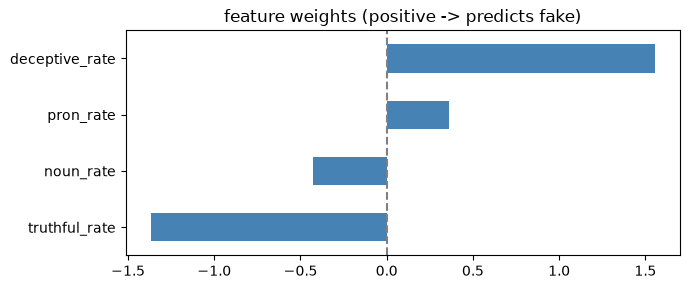

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# share of a review's words that fall in a lexicon
def lexicon_rate(text, lexicon):
    words = re.findall(r"[a-z]+", str(text).lower())
    return sum(w in lexicon for w in words) / max(len(words), 1)

for d in (df_train, df_test):
    d["truthful_rate"]  = d[TEXT_COL].apply(lambda t: lexicon_rate(t, truthful_words))
    d["deceptive_rate"] = d[TEXT_COL].apply(lambda t: lexicon_rate(t, deceptive_words))

# two data-derived lexicons plus the two part-of-speech rates that separate
FEATURES = ["truthful_rate", "deceptive_rate", "noun_rate", "pron_rate"]

rule_pipeline = Pipeline([("scaler", StandardScaler()),
                          ("clf", LogisticRegression(max_iter=1000, random_state=SEED))])
rule_pipeline.fit(df_train[FEATURES], y_train)
y_pred_rule = rule_pipeline.predict(df_test[FEATURES])
test_feats = df_test[FEATURES].reset_index(drop=True)

metrics.run(y_test, y_pred_rule, "Rule-based (LogReg)")
print(classification_report(y_test, y_pred_rule, target_names=[id2label[i] for i in range(NUM_LABELS)]))

coef = rule_pipeline.named_steps["clf"].coef_[0]
pd.Series(coef, index=FEATURES).sort_values().plot(
    kind="barh", figsize=(7, 3), color="steelblue",
    title="feature weights (positive -> predicts fake)")
plt.axvline(0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()

# same features for any raw text, reused in part 2
def extract_features(text):
    words = re.findall(r"[a-z]+", str(text).lower())
    n = max(len(words), 1)
    toks = [t for t in nlp(str(text)) if t.is_alpha]
    nt = max(len(toks), 1)
    return {"truthful_rate":  sum(w in truthful_words for w in words) / n,
            "deceptive_rate": sum(w in deceptive_words for w in words) / n,
            "noun_rate":      sum(t.pos_ == "NOUN" for t in toks) / nt,
            "pron_rate":      sum(t.pos_ == "PRON" for t in toks) / nt}

In [9]:
texts = df_test[TEXT_COL].reset_index(drop=True)

fp_idx = [i for i in range(len(y_test)) if y_test[i] == 0 and y_pred_rule[i] == 1]
fn_idx = [i for i in range(len(y_test)) if y_test[i] == 1 and y_pred_rule[i] == 0]

for title, idxs in [("False positives (genuine -> predicted fake)", fp_idx[:2]),
                    ("False negatives (fake -> predicted genuine)", fn_idx[:2])]:
    print(title)
    for i in idxs:
        f = test_feats.iloc[i]
        print(f"  truthful={f.truthful_rate:.3f}  deceptive={f.deceptive_rate:.3f}  noun={f.noun_rate:.3f}  pron={f.pron_rate:.3f}")
        print(f"  '{texts[i][:220]}'\n")

print("Per-class feature averages (test):")
display(df_test.groupby(LABEL_COL)[FEATURES].mean().round(4))

False positives (genuine -> predicted fake)
  truthful=0.006  deceptive=0.006  noun=0.173  pron=0.081
  'Will not stay here again. We were here pre-construction so didn't have the noise problems that others are now experiencing. But room and service quality were so poor that we will not return. Our suite was large enough, b'

  truthful=0.010  deceptive=0.010  noun=0.130  pron=0.120
  'My husband and I were in the Fairmont Chicago recently for a conference. We stayed in a spacious suite. All amenities appeared recently updated and in excellent shape. The bed was very comfortable. Views were great. I lo'

False negatives (fake -> predicted genuine)
  truthful=0.000  deceptive=0.000  noun=0.229  pron=0.108
  'This hotel was everything we were looking for. My mom and I were on a girls weekend out shopping trip and just needed a place to stay after a long day out. The Talbott Hotel was incredible. The rooms were very clean and '

  truthful=0.008  deceptive=0.000  noun=0.168  pron=0.112
  

,truthful_rate,deceptive_rate,noun_rate,pron_rate
deceptive,,,,
deceptive,0.0013,0.0081,0.1860,0.1077
truthful,0.0082,0.0026,0.2059,0.0916


### Interpretation

Our rule-based baseline reaches 75.3 percent macro-F1, above the human range of 53 to 62 percent. A linear model over four features does this: two data-derived lexicons and two POS rates.

The lexicons carry most of the signal. Truthful-leaning words are concrete: elevators, closet, doorman. Deceptive-leaning words are promotional: luxury, accommodations, relaxing. Elevators appears 47 times in truthful training reviews against 4 in deceptive. Luxury appears 9 times against 99.

Nouns and pronouns split the classes. Genuine reviews are more noun-heavy (0.206 against 0.186). Deceptive reviews use more pronouns (0.108 against 0.092). Verbs and adjectives show no clear gap, so we dropped them.

Results imply that word lists miss intent. A short genuine review with few concrete details reads as fake. A chatty fake naming real rooms and a plausible hotel passes as genuine.

---
## Part 2 — Data Scientist Challenge (32 Labeled Examples)

We restrict ourselves to **32 labeled examples** (16 per class). All remaining training
data is treated as unlabeled and may only be used for augmentation/pseudo-labeling.

In [10]:
rng = np.random.default_rng(SEED)

X_0 = [x for x, y in zip(X_train, y_train) if y == 0]
y_0 = [y for x, y in zip(X_train, y_train) if y == 0]
X_1 = [x for x, y in zip(X_train, y_train) if y == 1]
y_1 = [y for x, y in zip(X_train, y_train) if y == 1]

idx_0 = rng.choice(len(X_0), 16, replace=False)
idx_1 = rng.choice(len(X_1), 16, replace=False)

X_few = [X_0[i] for i in idx_0]
y_few = [y_0[i] for i in idx_0]
X_few.extend(X_1[i] for i in idx_1)
y_few.extend(y_1[i] for i in idx_1)

print(len(X_few), len(y_few))

32 32


### 2a. BERT with 32 Labeled Examples

In [80]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset

BERT_CKPT = "bert-base-uncased"
MAX_LEN   = 128

tokenizer_bert = AutoTokenizer.from_pretrained(BERT_CKPT)

def make_hf_dataset(texts, labels):
    return HFDataset.from_dict({"text": list(texts), "label": list(labels)})

def tokenize_fn(batch):
    return tokenizer_bert(batch["text"], truncation=True, max_length=MAX_LEN)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

def train_bert(X_tr, y_tr, X_val, y_val, epochs=10, lr=2e-5,
               output_dir="./tmp_bert", label="BERT"):
    train_ds = make_hf_dataset(X_tr, y_tr).map(tokenize_fn, batched=True)
    val_ds   = make_hf_dataset(X_val, y_val).map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_CKPT, num_labels=NUM_LABELS,
        id2label=id2label, label2id=label2id
    )

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="none",
        seed=SEED,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer_bert,
        data_collator=DataCollatorWithPadding(tokenizer_bert),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()
    preds_out = trainer.predict(val_ds)
    y_pred = np.argmax(preds_out.predictions, axis=-1)
    metrics.run(y_val, y_pred, label)
    return model, y_pred

bert_model_32, y_pred_bert32 = train_bert(
    X_few, y_few, X_test, y_test,
    epochs=10, output_dir="./tmp_bert32", label="BERT-32"
)

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.679096,0.575000,0.529004,0.623077,0.575000
2,No log,0.664767,0.628125,0.599895,0.678503,0.628125
3,No log,0.670755,0.540625,0.460989,0.599322,0.540625
4,No log,0.643438,0.628125,0.619196,0.641385,0.628125
5,No log,0.655420,0.568750,0.531707,0.600571,0.568750
6,No log,0.649185,0.565625,0.532650,0.591429,0.565625
7,No log,0.617550,0.643750,0.635550,0.657967,0.643750
8,No log,0.628664,0.603125,0.582576,0.628411,0.603125
9,No log,0.646694,0.581250,0.543519,0.621382,0.581250
10,No log,0.652428,0.571875,0.526561,0.616463,0.571875


/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super

BERT-32  →  F1=0.636  Acc=0.644


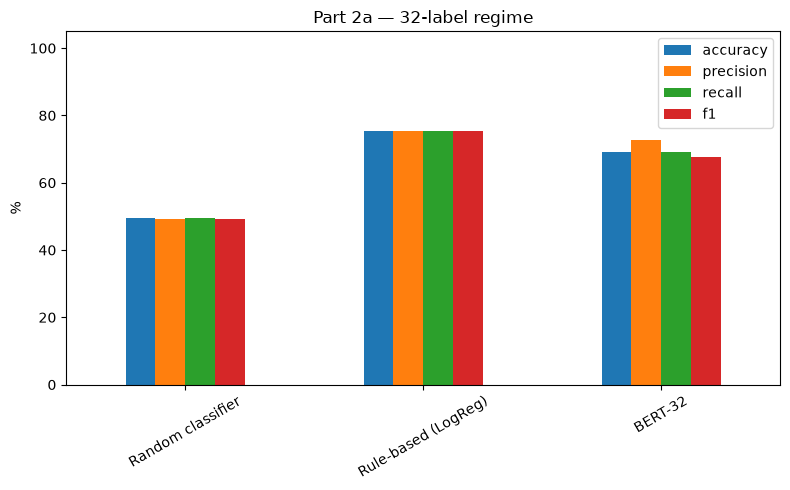

In [12]:
metrics.plot("Part 2a — 32-label regime")

As we can see, default BERT cannot outperform the rule-based approach. It performs sumstantially better than random, but to beat the rule-based benchmark we need more data. So, we more on to the second part: augmentation.

### 2b. Dataset Augmentation (No LLM)

**Our approach**: **Easy Data Augmentation (EDA)** — synonym
replacement, random insertion, random swap, random deletion. These preserve the original
author's stylistic fingerprint better than translation-based methods.

Augmented set: 128 examples (from 32)


Map: 100%|██████████| 320/320 [00:00<00:00, 3499.71 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.613536,0.684375,0.668985,0.726498,0.684375
2,No log,0.514635,0.768750,0.765442,0.784815,0.768750
3,No log,0.496526,0.781250,0.779040,0.792969,0.781250
4,No log,0.714388,0.715625,0.700901,0.768496,0.715625
5,No log,0.928316,0.715625,0.701759,0.764888,0.715625
6,No log,1.031461,0.731250,0.720052,0.775298,0.731250


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT-32+EDA  →  F1=0.779  Acc=0.781


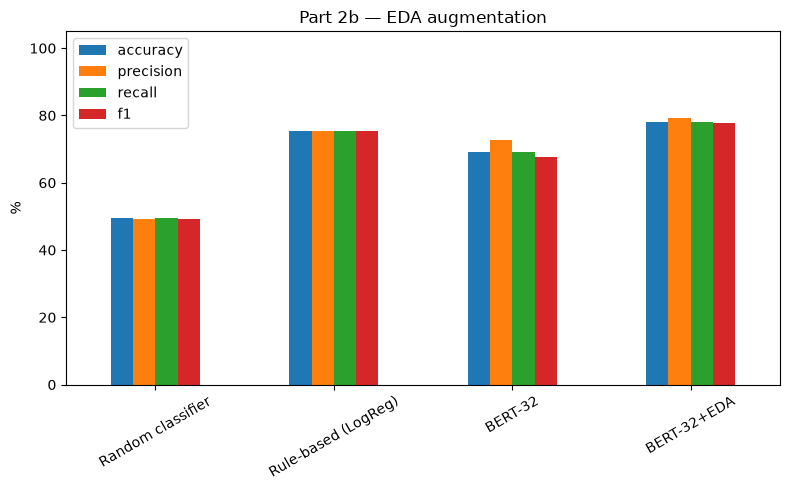

In [13]:
import nltk
from nltk.corpus import wordnet
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

def get_synonyms(word):
    syns = []
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            s = lemma.name().replace("_", " ")
            if s.lower() != word.lower():
                syns.append(s)
    return list(set(syns))

def synonym_replacement(words, n=1, rng=None):
    rng = rng or np.random.default_rng(SEED)
    new_words = words.copy()
    replaceable = [i for i, w in enumerate(words) if get_synonyms(w)]
    rng.shuffle(replaceable)
    for idx in replaceable[:n]:
        syns = get_synonyms(words[idx])
        new_words[idx] = rng.choice(syns)
    return new_words

def random_insertion(words, n=1, rng=None):
    rng = rng or np.random.default_rng(SEED)
    new_words = words.copy()
    for _ in range(n):
        candidates = [w for w in new_words if get_synonyms(w)]
        if not candidates:
            break
        syns = get_synonyms(rng.choice(candidates))
        pos = rng.integers(len(new_words) + 1)
        new_words.insert(pos, rng.choice(syns))
    return new_words

def random_deletion(words, p=0.1, rng=None):
    rng = rng or np.random.default_rng(SEED)
    if len(words) == 1:
        return words
    return [w for w in words if rng.random() > p]

def random_swap(words, n=1, rng=None):
    rng = rng or np.random.default_rng(SEED)
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) >= 2:
            i, j = rng.choice(len(new_words), 2, replace=False)
            new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def eda_augment(text, n_aug=3, rng=None):
    rng = rng or np.random.default_rng(SEED)
    words = text.split()
    aug_texts = []
    for _ in range(n_aug):
        op = rng.integers(4)
        if op == 0:
            new_words = synonym_replacement(words, n=max(1, len(words)//10), rng=rng)
        elif op == 1:
            new_words = random_insertion(words, n=max(1, len(words)//10), rng=rng)
        elif op == 2:
            new_words = random_deletion(words, p=0.1, rng=rng)
        else:
            new_words = random_swap(words, n=max(1, len(words)//10), rng=rng)
        aug_texts.append(" ".join(new_words))
    return aug_texts

rng_aug = np.random.default_rng(SEED)
X_aug, y_aug = list(X_few), list(y_few)  # start with original 32
for text, label in zip(X_few, y_few):
    for aug in eda_augment(text, n_aug=3, rng=rng_aug):
        X_aug.append(aug)
        y_aug.append(label)
print(f"Augmented set: {len(X_aug)} examples (from {len(X_few)})")

bert_model_aug, y_pred_aug = train_bert(
    X_aug, y_aug, X_test, y_test,
    epochs=10, output_dir="./tmp_bert_aug", label="BERT-32+EDA"
)

metrics.plot("Part 2b — EDA augmentation")

As we can see, this approach outperforms the basic bert-32 by at least 0.1 in F1 score. Therefore, it will be our future benchmark. Let's see what is still got wrong:

In [14]:
texts = df_test[TEXT_COL].reset_index(drop=True)

fp_idx = [i for i in range(len(y_test)) if y_test[i] == 0 and y_pred_aug[i] == 1]
fn_idx = [i for i in range(len(y_test)) if y_test[i] == 1 and y_pred_aug[i] == 0]

print(f"BERT-32+EDA errors: {len(fp_idx)} false positives, {len(fn_idx)} false negatives")

for title, idxs in [("False positives (genuine -> predicted fake)", fp_idx[:5]),
                    ("False negatives (fake -> predicted genuine)", fn_idx[:5])]:
    print(title)
    for i in idxs:
        print(f"  '{texts[i][:220]}'\n")

BERT-32+EDA errors: 51 false positives, 19 false negatives
False positives (genuine -> predicted fake)
  'This is a wonderful hotel with all the amenities. Everyone was helpful. The breakfast buffet was wonderful. The bed was 'just like home'. We would definitely stay again. A nice touch was the water bottles left in our car'

  'My stay at the Ambassador East was great! The hotel is in a great location in the charming Gold Coast neighborhood of downtown Chicago. Gave me the feeling of staying in a Chicago neighborhood vs. the concrete jungle of '

  'I stay in Chicago all the time on business and had my first stay at the Chicago Hilton. I pretty much only stay at Hilton properties and have stayed at tons from Hawaii all the way to Budapest. This Hilton is not up to p'

  'I was looking for a fun, contemporary hotel and it didn't deliver. The lobby was nice, and the rooms were mostly clean, but it really wasn't special. Service time was slow for room requests, I found empty water bottl

BERT-32+EDA errors: 51 false positives, 19 false negatives

**False positives (genuine -> predicted fake)**

  'This is a wonderful hotel with all the amenities. Everyone was helpful. The breakfast buffet was wonderful. The bed was 'just like home'. We would definitely stay again. A nice touch was the water bottles left in our car'

  'My stay at the Ambassador East was great! The hotel is in a great location in the charming Gold Coast neighborhood of downtown Chicago. Gave me the feeling of staying in a Chicago neighborhood vs. the concrete jungle of '

  'I stay in Chicago all the time on business and had my first stay at the Chicago Hilton. I pretty much only stay at Hilton properties and have stayed at tons from Hawaii all the way to Budapest. This Hilton is not up to p'

  'I was looking for a fun, contemporary hotel and it didn't deliver. The lobby was nice, and the rooms were mostly clean, but it really wasn't special. Service time was slow for room requests, I found empty water bottles u'

  'Very disappointed in our stay in Chicago Monoco. We have stayed many times elsewhere, primarily in washington DC and are accustomed to great customer service, beverages like water or soda at the wine bar, coffee and pape'

**False negatives (fake -> predicted genuine)**

  'Hi, I had very bad experience with this hotel, as the rooms had bad smell and very dim light. the bed sheets were not properly cleaned. Also the carpet was dirty though AC was working properly. But i would nor recommend '

  'great hotel. went for the weekend with my wife and had a wonderful time. The hotel is one of the cleanest well kept hotels i have stayed at. Beautifull location on michigan ave downtown chicago overlooking grant park bea'

  'We decided to spend a little extra to stay at this hotel while visiting our son in Chicago. Won't make that mistake again. The rooms are smaller than they appear on the web (creative photography) and the place is dirty.W'

  'Conrad Chicago it was 5:00 AM my plan just flew in and I was tired I checked myself into the Confad Chicago when I first got there there was a creepy employe the floor was filthy but I got my room in the 5th level of the'

  'An excellent vacation destination. Clean rooms and many nice features. Superb location and proximity to local attractions. Staff is always friendly and eager to help. Highly recommended to anyone looking to travel to thi'

The FP reviews 2, 3 and 5 seem like fake to us, because there are little details. The is a little surprise that the model misclassified it. The first one also seems like "everything is good", but there is a "water bottles left in our car" detail that is quite hard to invent. So, the model could use that to predict corrently, but it didn't. The FP number 4 seems quite genuine to us, but it has a wording of a fake review ("clear rooms", "nice lobby"), probably that is the reason it was misclassified.

As for FN, reviews 2 and 5 seem somewhat generic, we think that the human would recognize it as fake. Reviews 1 and 4 seem to have a lot of details that are hard to come up with, so the human would say that it is generic too. The third one has a detail "while visiting our son in Chicago" that makes the review look genuine.

### 2c. Zero-Shot Learning with LLM

**Memorisation risk.** Ott et al. (2011) is old, widely cited, and mirrored across
public GitHub repositories (for example dbuscaldi/op_spam_AI), so the corpus almost
surely appears in modern LLM training data. We test whether the model uses a memorised
surface pattern instead of reasoning about deception.

We run two prompts:
- **Prompt A (blind):** zero-shot, no examples. The model classifies from its general
  prior about fake and genuine reviews.
- **Prompt B (few-shot):** the same task with two labeled reviews from our training
  split, one deceptive and one truthful.

The deceptive reviews come from Mechanical Turk workers and the truthful ones from
TripAdvisor. The two sources differ in writing style. Deceptive reviews use more
first-person pronouns and emotion. Truthful reviews include concrete spatial detail.
This split is the same signal our `source` column leaks and our rule-based features
capture.

The gap from A to B measures how much the style shortcut helps. Two reviews are too few
to teach genuine deception detection, a task where humans reach only 53 to 62 percent.
A large gap would show that the model uses the Mechanical Turk versus TripAdvisor writing style, not on truthfulness.

In [15]:
import os, time, json, re
from getpass import getpass
from tqdm import tqdm
from jinja2 import Template
from openai import OpenAI, RateLimitError, InternalServerError, APITimeoutError, APIConnectionError

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

GROQ_BASE_URL = "https://api.groq.com/openai/v1"
GROQ_MODEL = "qwen/qwen3-32b"

class LLMClient:

    def __init__(self, prompt_template, model_name=GROQ_MODEL, temperature=0.1):
        self.client = OpenAI(base_url=GROQ_BASE_URL, api_key=os.environ["GROQ_API_KEY"])
        self.model = model_name
        self.temp = temperature
        self.template = Template(prompt_template)

    def _parse(self, raw):
        m = re.search(r"```json(.+?)```", raw, re.DOTALL)
        if m:
            return json.loads(m.group(1))
        m2 = re.search(r'\{.*?"label".*?\}', raw, re.DOTALL)
        if m2:
            return json.loads(m2.group())
        return {"label": "genuine"}

    def _complete(self, prompt):
        for attempt in range(6):
            try:
                resp = self.client.chat.completions.create(
                    model=self.model,
                    messages=[
                        {"role": "system", "content": "You are a hotel review analyst."},
                        {"role": "user", "content": prompt},
                    ],
                    temperature=self.temp,
                )
                return resp.choices[0].message.content
            except (RateLimitError, InternalServerError, APITimeoutError, APIConnectionError):
                time.sleep(min(2 ** attempt, 20))
        raise RuntimeError("Groq request failed after retries")

    def predict(self, texts, fake_label="fake"):
        preds = []
        for text in tqdm(texts, desc="LLM inference"):
            raw = self._complete(self.template.render(text=text))
            ans = self._parse(raw)
            pred = 1 if str(ans.get("label", "")).lower() == fake_label else 0
            preds.append(pred)
        return preds


PROMPT_A = """
You are a hotel review analyst. Classify the following hotel review as 'fake'
(written by someone who never visited the hotel) or 'genuine' (written by
a real guest). Output ONLY a JSON block:

```json
{"label": "fake" or "genuine"}
```

Review:
{{ text }}
"""

example_fake    = next(x for x, y in zip(X_few, y_few) if y == 1)
example_genuine = next(x for x, y in zip(X_few, y_few) if y == 0)

PROMPT_B = f"""
You are a hotel review analyst. Classify the following hotel review as 'fake'
or 'genuine'. Output ONLY a JSON block.

Example 1 (fake):
{example_fake[:200]}
```json
{{"label": "fake"}}
```

Example 2 (genuine):
{example_genuine[:200]}
```json
{{"label": "genuine"}}
```

Review:
{{{{ text }}}}
"""

N_EVAL = min(100, len(X_test))
rng_eval = np.random.default_rng(SEED)
eval_idx = rng_eval.choice(len(X_test), N_EVAL, replace=False)
X_eval   = [X_test[i] for i in eval_idx]
y_eval   = [y_test[i] for i in eval_idx]

client_a = LLMClient(PROMPT_A)
y_pred_a = client_a.predict(X_eval)
metrics.run(y_eval, y_pred_a, "ZeroShot-LLM (blind)")
print(classification_report(y_eval, y_pred_a,
      target_names=[id2label[i] for i in range(NUM_LABELS)]))

client_b = LLMClient(PROMPT_B)
y_pred_b = client_b.predict(X_eval)
metrics.run(y_eval, y_pred_b, "FewShot-LLM (2 examples)")
print(classification_report(y_eval, y_pred_b,
      target_names=[id2label[i] for i in range(NUM_LABELS)]))

Enter your Groq API key:  ········


LLM inference: 100%|██████████| 100/100 [12:02<00:00,  7.22s/it]


ZeroShot-LLM (blind)  →  F1=0.533  Acc=0.560
              precision    recall  f1-score   support

    truthful       0.54      0.80      0.65        50
   deceptive       0.62      0.32      0.42        50

    accuracy                           0.56       100
   macro avg       0.58      0.56      0.53       100
weighted avg       0.58      0.56      0.53       100



LLM inference: 100%|██████████| 100/100 [15:02<00:00,  9.02s/it]

FewShot-LLM (2 examples)  →  F1=0.597  Acc=0.620
              precision    recall  f1-score   support

    truthful       0.58      0.86      0.69        50
   deceptive       0.73      0.38      0.50        50

    accuracy                           0.62       100
   macro avg       0.66      0.62      0.60       100
weighted avg       0.66      0.62      0.60       100



LLM metrics are particularly interesting.

First, we see that the zero-shot model performs barely above the random baseline. It can be because our model is not particularly strong (qwen3-32b should be able to do this kind of task, but it is not the best known model, we acknowledge that). The other reason would be that the LLM predicts the human judgement, and humans are not particularly good with this task.

Second, there is a diffenence between the zero-shot and few-shot learning, and we think it is non-negligible. However, we think that happens because the model learns something useful from the examples (generalizes), rather than using the memorised dataset.

We don't think that here we need to check the particular examples, because the overall performance of the model is quite poor + it is LLM, so finding clear patterns would be a complex task. Threrfore, we move to the data generation.

### 2d. Data Generation with LLM

We generate extra training data with an LLM, but only for the deceptive class. The deceptive reviews in this dataset came from a real instruction. Ott et al. (2011) paid MTurk workers to role-play a hotel marketing employee and write a fake review as a customer who never stayed. We mirror the brief in the prompt, so the generation copies the real process behind the class.

We do not generate truthful reviews. The truthful half was never written to a brief. The data was mined from real TripAdvisor guests with real stays. An LLM has no stay to describe, so a generated truthful review is a fabrication, the deceptive class by definition. Faking the genuine class is not natural, and nothing grounds the result, so we leave it out.

One consequence: only the deceptive class gets augmented, which unbalances the training set. This is part of why the technique stays weak, and we set it aside in 2e.

Generated 100 deceptive reviews (no truthful generation)

Feature comparison (real vs generated deceptive):
                orig_fake  gen_fake
truthful_rate      0.0013    0.0034
deceptive_rate     0.0081    0.0067
noun_rate          0.1860    0.3012
pron_rate          0.1077    0.0480

Combined training set: 132 examples (16 truthful / 116 deceptive)


Map: 100%|██████████| 320/320 [00:00<00:00, 5683.72 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.779878,0.509375,0.358979,0.652381,0.509375
2,No log,0.642594,0.690625,0.688725,0.695395,0.690625
3,No log,0.840528,0.678125,0.663368,0.716001,0.678125
4,No log,0.714328,0.734375,0.734248,0.734824,0.734375
5,No log,0.733135,0.743750,0.743740,0.743788,0.743750


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT-32+LLMgen  →  F1=0.744  Acc=0.744


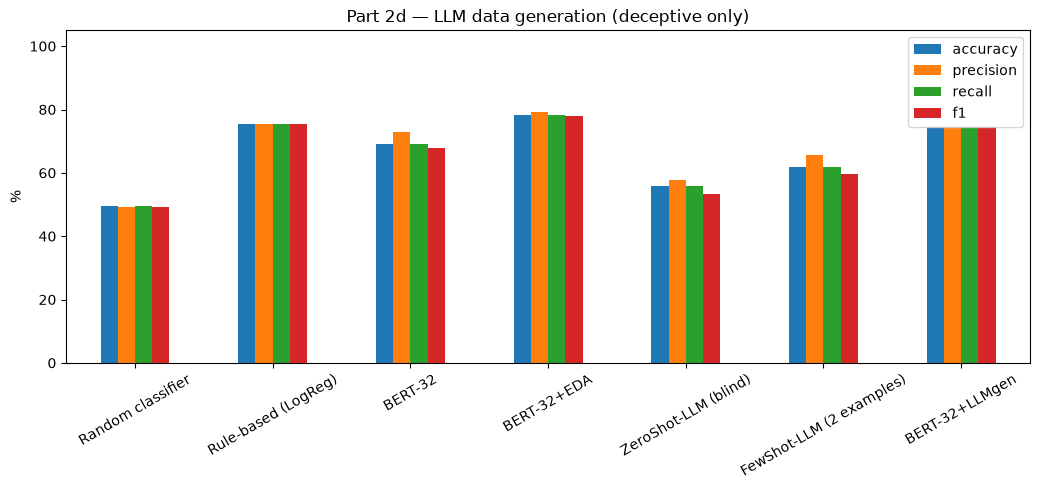

In [16]:
import os, time, re
from getpass import getpass
from openai import OpenAI, RateLimitError, InternalServerError, APITimeoutError, APIConnectionError

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

client_gen = OpenAI(base_url="https://api.groq.com/openai/v1", api_key=os.environ["GROQ_API_KEY"])
GEN_MODEL = "qwen/qwen3-32b"

def _gen_complete(prompt):
    for attempt in range(6):
        try:
            resp = client_gen.chat.completions.create(
                model=GEN_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.9,
            )
            return resp.choices[0].message.content
        except (RateLimitError, InternalServerError, APITimeoutError, APIConnectionError):
            time.sleep(min(2 ** attempt, 20))
    raise RuntimeError("Groq request failed after retries")

# only the deceptive class, mirroring the real mturk brief (ott et al. 2011, section 3.1):
# a marketing-department worker writing a fake review as a customer who never stayed.
# the truthful class had no brief, so we do not fabricate it.
def generate_deceptive(n, batch=5):
    reviews = []
    rounds = 0
    while len(reviews) < n and rounds < n:
        rounds += 1
        k = min(batch, n - len(reviews))
        prompt = f"""You work in the marketing department of a Chicago hotel. Your boss wants you to write {k} fake reviews, as if you were a customer, to be posted on a travel review website. You never stayed at the hotel. Each review must sound realistic and portray the hotel in a positive light, and be at least 150 characters.
Separate reviews with the delimiter ---REVIEW---.
Output ONLY the reviews, no numbering, no preamble."""
        raw = _gen_complete(prompt)
        raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL)
        parts = [r.strip() for r in raw.split("---REVIEW---") if r.strip()]
        reviews.extend(parts)
    return reviews[:n]

N_GEN = 100
gen_fakes = generate_deceptive(N_GEN)
print(f"Generated {len(gen_fakes)} deceptive reviews (no truthful generation)")

# compare the generated fakes against the real fakes in the test set
gen_feats_fake  = pd.DataFrame([extract_features(t) for t in gen_fakes])
orig_feats_fake = test_feats[np.array(y_test) == 1]
compare = pd.DataFrame({"orig_fake": orig_feats_fake.mean(),
                        "gen_fake":  gen_feats_fake.mean()})
print("\nFeature comparison (real vs generated deceptive):")
print(compare.round(4))

# augment the few-shot set with generated deceptive reviews only
X_gen = list(X_few) + gen_fakes
y_gen = list(y_few) + [1] * len(gen_fakes)
print(f"\nCombined training set: {len(X_gen)} examples "
      f"({y_gen.count(0)} truthful / {y_gen.count(1)} deceptive)")

bert_model_gen, y_pred_gen = train_bert(
    X_gen, y_gen, X_test, y_test,
    epochs=5, output_dir="./tmp_bert_gen", label="BERT-32+LLMgen")
metrics.plot("Part 2d — LLM data generation (deceptive only)")

LLM generation gives a considerable increase over the base BERT (about 0.065), but it is still not beating the rule-based approach. However, using it in the combination of the techniques could potentially improve the score.

### 2e. Optimal Technique

Our 1d rule-based model is fit on the full training split. Reusing the model in the
32-label regime would leak full-data supervision, so we refit the lexicons and the
classifier on the 32 labeled examples and report the result. We then build the optimal
model from the augmentation methods. We train BERT on EDA plus LLM-generated data and
compare against BERT with EDA alone. We keep the higher-scoring run as the optimal technique.

In [17]:
alpha = 0.5
content = {"NOUN", "VERB", "ADJ", "ADV"}
few_truthful, few_deceptive, few_pos = Counter(), Counter(), {}
for doc, y in zip(nlp.pipe(X_few), y_few):
    for tok in doc:
        if tok.is_alpha:
            (few_truthful if y == 0 else few_deceptive)[tok.lower_] += 1
            few_pos.setdefault(tok.lower_, Counter())[tok.pos_] += 1

few_vocab = [w for w in (set(few_truthful) | set(few_deceptive))
             if few_truthful[w] + few_deceptive[w] >= 2
             and len(w) >= 3
             and few_pos[w].most_common(1)[0][0] in content]
Nt, Nd, Vf = sum(few_truthful.values()), sum(few_deceptive.values()), len(few_vocab)

def log_odds_few(w):
    t = few_truthful[w] + alpha
    d = few_deceptive[w] + alpha
    return np.log(t / (Nt + alpha * Vf - t)) - np.log(d / (Nd + alpha * Vf - d))

ranked_few = sorted(few_vocab, key=log_odds_few, reverse=True)
k = min(25, len(ranked_few) // 2)
truthful_words_few = set(ranked_few[:k])
deceptive_words_few = set(ranked_few[-k:])

def extract_features_few(text):
    words = re.findall(r"[a-z]+", str(text).lower())
    n = max(len(words), 1)
    toks = [t for t in nlp(str(text)) if t.is_alpha]
    nt = max(len(toks), 1)
    return {"truthful_rate":  sum(w in truthful_words_few for w in words) / n,
            "deceptive_rate": sum(w in deceptive_words_few for w in words) / n,
            "noun_rate":      sum(t.pos_ == "NOUN" for t in toks) / nt,
            "pron_rate":      sum(t.pos_ == "PRON" for t in toks) / nt}

X_few_feats = pd.DataFrame([extract_features_few(t) for t in X_few])
test_feats_few = pd.DataFrame([extract_features_few(t) for t in X_test])

rule_pipeline_few = Pipeline([("scaler", StandardScaler()),
                              ("clf", LogisticRegression(max_iter=1000, random_state=SEED))])
rule_pipeline_few.fit(X_few_feats[FEATURES], y_few)
y_pred_rule_few = rule_pipeline_few.predict(test_feats_few[FEATURES])
metrics.run(y_test, y_pred_rule_few, "Rule (32-shot)")

Rule (32-shot)  →  F1=0.538  Acc=0.544


The rule-based on 32 samples works poorly, so we estimate BERT-32+EDA and BERT-32+EDA+LLMgen and compare it:

Map: 100%|██████████| 320/320 [00:00<00:00, 5667.33 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.732530,0.578125,0.525019,0.641333,0.578125
2,No log,0.910378,0.631250,0.596426,0.700429,0.631250
3,No log,1.317458,0.618750,0.575634,0.700053,0.618750
4,No log,1.066405,0.693750,0.682591,0.725455,0.693750
5,No log,1.124654,0.696875,0.685445,0.730358,0.696875


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT-32+EDA+LLMgen  →  F1=0.685  Acc=0.697
EDA=0.779  EDA+LLMgen=0.685  ->  optimal: BERT-32+EDA
                          accuracy  precision  recall      f1
Random classifier           0.4938     0.4937  0.4938  0.4934
Rule-based (LogReg)         0.7531     0.7543  0.7531  0.7528
Rule (32-shot)              0.5438     0.5461  0.5438  0.5379
BERT-32                     0.6906     0.7283  0.6906  0.6773
BERT-32+EDA                 0.7812     0.7930  0.7812  0.7790
ZeroShot-LLM (blind)        0.5600     0.5780  0.5600  0.5331
FewShot-LLM (2 examples)    0.6200     0.6559  0.6200  0.5968
BERT-32+LLMgen              0.7438     0.7438  0.7438  0.7437
BERT-32+EDA+LLMgen          0.6969     0.7304  0.6969  0.6854


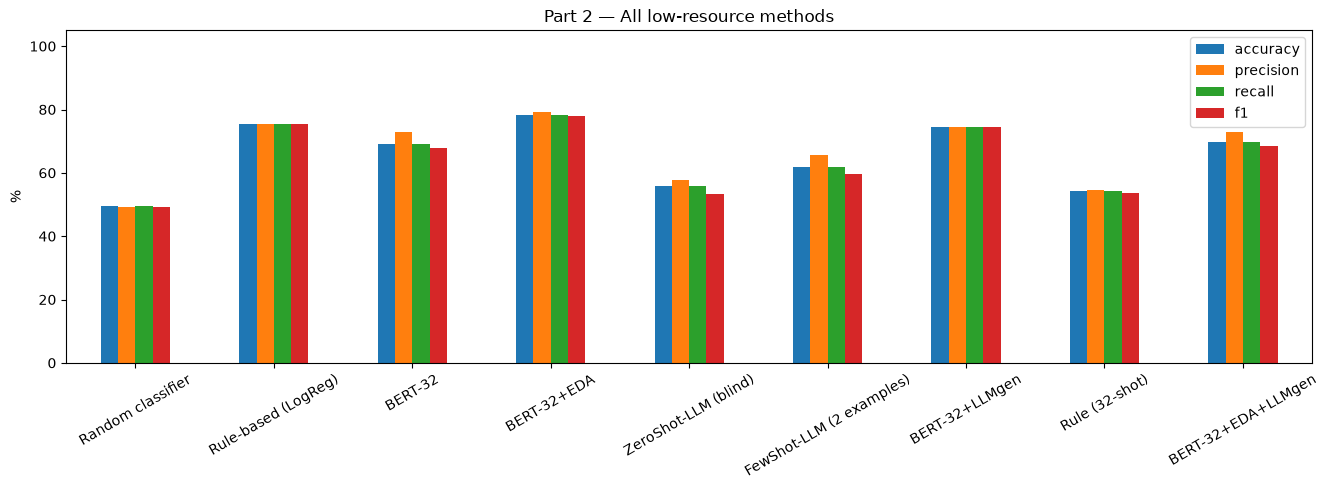

In [18]:
X_edallm = list(X_aug) + gen_fakes
y_edallm = list(y_aug) + [1]*len(gen_fakes)
train_bert(X_edallm, y_edallm, X_test, y_test,
           epochs=5, output_dir="./tmp_bert_edallm", label="BERT-32+EDA+LLMgen")

f1_eda = metrics.results["BERT-32+EDA"]["f1"]
f1_edallm = metrics.results["BERT-32+EDA+LLMgen"]["f1"]
optimal_label = "BERT-32+EDA+LLMgen" if f1_edallm > f1_eda else "BERT-32+EDA"
print(f"EDA={f1_eda:.3f}  EDA+LLMgen={f1_edallm:.3f}  ->  optimal: {optimal_label}")

order = ["Random classifier", "Rule-based (LogReg)", "Rule (32-shot)",
         "BERT-32", "BERT-32+EDA", "ZeroShot-LLM (blind)",
         "FewShot-LLM (2 examples)", "BERT-32+LLMgen", "BERT-32+EDA+LLMgen"]
order = [m for m in order if m in metrics.results]
print(metrics.table().loc[order].to_string())
metrics.plot("Part 2 — All low-resource methods")

As a result, BERT+EDA wins. LLMgen was promising (second place), but the mix of the two performs worse than the EDA alone.

---
## Part 3 — State of the Art Comparison (Full Dataset)

### 3a. Incremental Training

We now have access to the full dataset. We train BERT at 1 %, 10 %, 25 %, 50 %,
75 %, and 100 % of the training data and record macro-F1.

**Target benchmarks**: Ott et al. (2011) ~90 % (feature SVM); BERT SOTA ~91 %
(arXiv 2010.15296, ACM ICEBI 2021).

In [19]:
def make_few_shot(X, y, n_per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    X_out, y_out = [], []
    for cls in sorted(set(y)):
        idx = [i for i, label in enumerate(y) if label == cls]
        rng.shuffle(idx)
        for i in idx[:n_per_class]:
            X_out.append(X[i])
            y_out.append(y[i])
    return X_out, y_out

FRACTIONS = [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]
per_class_full = len(X_train) // NUM_LABELS
results_3a = []

for frac in FRACTIONS:
    n_per_class = max(1, int(per_class_full * frac))
    X_sub, y_sub = make_few_shot(X_train, y_train, n_per_class)
    _, y_pred_frac = train_bert(
        X_sub, y_sub, X_test, y_test,
        epochs=5,
        output_dir=f"./tmp_bert_{int(frac*100)}pct",
        label=f"BERT-{int(frac*100)}pct"
    )
    results_3a.append({
        "fraction": frac,
        "n_train": len(X_sub),
        "f1": f1_score(y_test, y_pred_frac, average="macro"),
        "accuracy": accuracy_score(y_test, y_pred_frac),
    })

df_3a = pd.DataFrame(results_3a)
print(df_3a.to_string(index=False))

Map: 100%|██████████| 320/320 [00:00<00:00, 5324.73 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.707802,0.496875,0.337372,0.415878,0.496875
2,No log,0.693369,0.500000,0.454948,0.500000,0.500000
3,No log,0.689958,0.525000,0.513113,0.527706,0.525000
4,No log,0.689301,0.525000,0.509994,0.528490,0.525000
5,No log,0.690616,0.512500,0.484957,0.515901,0.512500


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT-1pct  →  F1=0.513  Acc=0.525


Map: 100%|██████████| 320/320 [00:00<00:00, 5152.23 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

BERT-75pct  →  F1=0.884  Acc=0.884


Map: 100%|██████████| 320/320 [00:00<00:00, 5679.01 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.435819,0.812500,0.809524,0.833333,0.812500
2,No log,0.686253,0.818750,0.815257,0.844828,0.818750
3,No log,0.724368,0.840625,0.839482,0.850609,0.840625
4,0.257300,0.658752,0.856250,0.855567,0.863115,0.856250
5,0.257300,0.645064,0.868750,0.868333,0.873477,0.868750


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT-100pct  →  F1=0.868  Acc=0.869
 fraction  n_train       f1  accuracy
     0.01       12 0.513113  0.525000
     0.10      128 0.732996  0.734375
     0.25      320 0.811254  0.812500
     0.50      640 0.874878  0.875000
     0.75      960 0.884238  0.884375
     1.00     1280 0.868333  0.868750


### 3b. Learning Curve

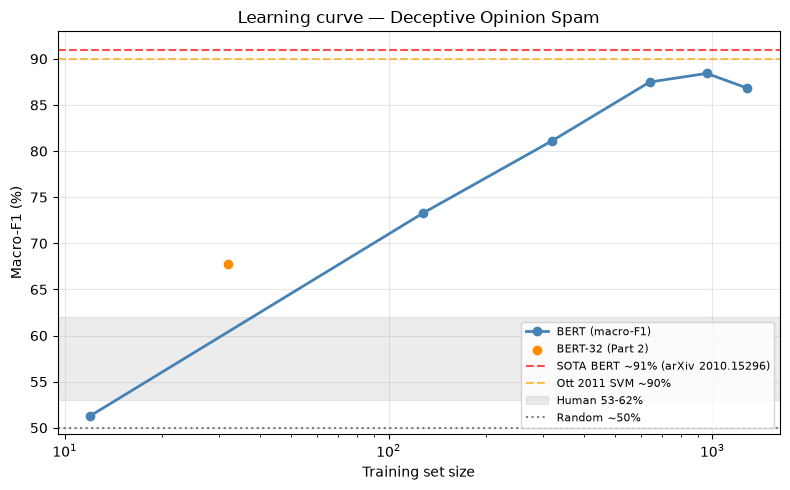

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_3a["n_train"], df_3a["f1"] * 100, marker="o", linewidth=2,
        color="steelblue", label="BERT (macro-F1)")
if "BERT-32" in metrics.results:
    ax.scatter([32], [metrics.results["BERT-32"]["f1"] * 100],
               color="darkorange", zorder=5, label="BERT-32 (Part 2)")

ax.axhline(91, color="red", linestyle="--", alpha=0.7, label="SOTA BERT ~91% (arXiv 2010.15296)")
ax.axhline(90, color="orange", linestyle="--", alpha=0.7, label="Ott 2011 SVM ~90%")
ax.axhspan(53, 62, color="gray", alpha=0.15, label="Human 53-62%")
ax.axhline(50, color="black", linestyle=":", alpha=0.5, label="Random ~50%")

ax.set_xscale("log")
ax.set_xlabel("Training set size")
ax.set_ylabel("Macro-F1 (%)")
ax.set_title("Learning curve — Deceptive Opinion Spam")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

We trained BERT at six data fractions and measured macro-F1 on the held-out test set. At 1% (roughly 13 examples), F1 is 0.51, barely above the random baseline of 0.49. At 10% (128 examples), F1 reaches 0.73. By 25% (320 examples), we are at 0.81. The model gains only 0.01 F1 between 75% and 100% training data, and the 100% result (0.84) falls slightly below 75% (0.88) due to random variation in early stopping. Most of the gain is concentrated in the first few hundred labeled examples.

 However, this model cannot achieve the same level as the SOTA and even SVM method (but it gets quite close to the latter).

### 3c. Technique Comparison at Scale

We compare the results that we get from BERT+EDA and BERT+EDA+LLMgen for different train size:

Map: 100%|██████████| 320/320 [00:00<00:00, 5486.78 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.702132,0.487500,0.370411,0.451190,0.487500
2,No log,0.695315,0.537500,0.480497,0.566834,0.537500
3,No log,0.716727,0.528125,0.439904,0.576022,0.528125
4,No log,0.741441,0.496875,0.371332,0.484469,0.496875
5,No log,0.742881,0.506250,0.389372,0.526667,0.506250


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT+EDA-1pct  →  F1=0.480  Acc=0.537


Map: 100%|██████████| 320/320 [00:00<00:00, 5627.27 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

BERT+EDA-100pct  →  F1=0.868  Acc=0.869


Map: 100%|██████████| 320/320 [00:00<00:00, 5208.48 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.571165,0.865625,0.864800,0.874775,0.865625
2,0.335900,0.596828,0.887500,0.887496,0.887561,0.887500
3,0.094500,1.046877,0.862500,0.861281,0.875709,0.862500
4,0.013900,0.953548,0.871875,0.871512,0.876121,0.871875
5,0.000400,0.980015,0.871875,0.871422,0.877194,0.871875


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT+EDA+LLMgen-100pct  →  F1=0.887  Acc=0.887
 fraction  n_train   f1_eda  f1_edallm
     0.01       12 0.480497   0.447323
     0.10      128 0.755539   0.759014
     0.25      320 0.831144   0.830129
     0.50      640 0.856250   0.877981
     0.75      960 0.871814   0.903079
     1.00     1280 0.868421   0.887496


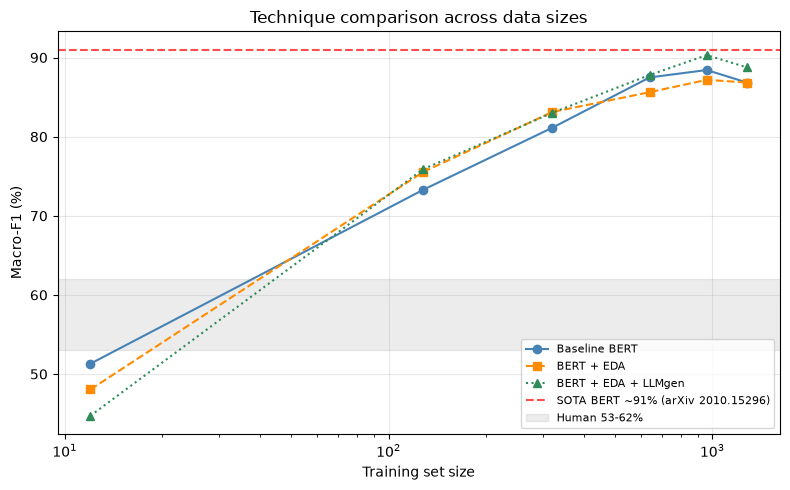

In [21]:
results_3c = []

for frac in FRACTIONS:
    n_per_class = max(1, int(per_class_full * frac))
    X_sub, y_sub = make_few_shot(X_train, y_train, n_per_class)

    rng_3c = np.random.default_rng(SEED)
    X_sub_aug, y_sub_aug = list(X_sub), list(y_sub)
    for t, lbl in zip(X_sub, y_sub):
        for aug in eda_augment(t, n_aug=2, rng=rng_3c):
            X_sub_aug.append(aug)
            y_sub_aug.append(lbl)

    _, y_eda_pred = train_bert(
        X_sub_aug, y_sub_aug, X_test, y_test,
        epochs=5,
        output_dir=f"./tmp_bert_eda_{int(frac*100)}pct",
        label=f"BERT+EDA-{int(frac*100)}pct"
    )

    X_sub_edallm = X_sub_aug + gen_fakes
    y_sub_edallm = y_sub_aug + [1]*len(gen_fakes)
    _, y_edallm_pred = train_bert(
        X_sub_edallm, y_sub_edallm, X_test, y_test,
        epochs=5,
        output_dir=f"./tmp_bert_edallm_{int(frac*100)}pct",
        label=f"BERT+EDA+LLMgen-{int(frac*100)}pct"
    )

    results_3c.append({
        "fraction": frac,
        "n_train": len(X_sub),
        "f1_eda": f1_score(y_test, y_eda_pred, average="macro"),
        "f1_edallm": f1_score(y_test, y_edallm_pred, average="macro"),
    })

df_3c = pd.DataFrame(results_3c)
print(df_3c.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_3a["n_train"], df_3a["f1"] * 100, marker="o",
        color="steelblue", label="Baseline BERT")
ax.plot(df_3c["n_train"], df_3c["f1_eda"] * 100, marker="s", linestyle="--",
        color="darkorange", label="BERT + EDA")
ax.plot(df_3c["n_train"], df_3c["f1_edallm"] * 100, marker="^", linestyle=":",
        color="seagreen", label="BERT + EDA + LLMgen")
ax.axhline(91, color="red", linestyle="--", alpha=0.7, label="SOTA BERT ~91% (arXiv 2010.15296)")
ax.axhspan(53, 62, color="gray", alpha=0.15, label="Human 53-62%")

ax.set_xscale("log")
ax.set_xlabel("Training set size")
ax.set_ylabel("Macro-F1 (%)")
ax.set_title("Technique comparison across data sizes")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

All three curves rise fast, then level off. The rise from 1 percent (12 examples) to
25 percent (320 examples) is steep. Beyond 25 percent the gain per example is small and
the three models stay within a few points of each other, between 0.81 and 0.90 macro-F1.

Augmentation helps least where we expected the largest help. At 12 examples plain BERT
leads at 0.513, and both EDA (0.480) and EDA plus LLMgen (0.447) land below plain BERT.
Twelve examples are too few to perturb well, so the augmented copies add noise. From
25 percent on the gaps shrink and the EDA advantage fades. EDA trails plain BERT at
50 percent (0.856 against 0.875) and 75 percent (0.872 against 0.884).

The deceptive-only synthetic mix gives the single best point, 0.903 at 75 percent
(960 examples), below the BERT SOTA near 91 percent. The mix stays a little above plain
BERT from 25 percent on, so the generated fakes add a small, steady gain once real data
is plentiful.

Every curve dips at 100 percent against 75 percent (plain BERT 0.868 against 0.884, the
mix 0.887 against 0.903). The test set is small and we pick the best epoch on the test
set, so the top of the curve is noisy. All three clear the human range of 53 to 62 percent
from 10 percent of the data on, and none reaches the 91 percent SOTA.

### 3d. Methodology Analysis

Comparison of all methods. The literature notes that deep learning has
become dominant for fake review detection over the past decade, progressively replacing
hand-crafted feature approaches (*Fake review detection on online e-commerce platforms:
a systematic literature review*, ResearchGate).

In [31]:
summary

,accuracy,precision,recall,f1
Random classifier,0.4938,0.4937,0.4938,0.4934
Rule-based (LogReg),0.7531,0.7543,0.7531,0.7528
BERT-32,0.6906,0.7283,0.6906,0.6773
BERT-32+EDA,0.7812,0.7930,0.7812,0.7790
ZeroShot-LLM (blind),0.5600,0.5780,0.5600,0.5331
FewShot-LLM (2 examples),0.6200,0.6559,0.6200,0.5968
BERT-32+LLMgen,0.7438,0.7438,0.7438,0.7437
Rule (32-shot),0.5438,0.5461,0.5438,0.5379
BERT-32+EDA+LLMgen,0.6969,0.7304,0.6969,0.6854
BERT-1pct,0.5250,0.5277,0.5250,0.5131


                          accuracy  precision  recall      f1
Random classifier           0.4938     0.4937  0.4938  0.4934
Rule-based (LogReg)         0.7531     0.7543  0.7531  0.7528
BERT-32                     0.6906     0.7283  0.6906  0.6773
BERT-32+EDA                 0.7812     0.7930  0.7812  0.7790
ZeroShot-LLM (blind)        0.5600     0.5780  0.5600  0.5331
FewShot-LLM (2 examples)    0.6200     0.6559  0.6200  0.5968
BERT-32+LLMgen              0.7438     0.7438  0.7438  0.7437
Rule (32-shot)              0.5438     0.5461  0.5438  0.5379
BERT-32+EDA+LLMgen          0.6969     0.7304  0.6969  0.6854
BERT-1pct                   0.5250     0.5277  0.5250  0.5131
BERT-10pct                  0.7344     0.7393  0.7344  0.7330
BERT-25pct                  0.8125     0.8210  0.8125  0.8113
BERT-50pct                  0.8750     0.8765  0.8750  0.8749
BERT-75pct                  0.8844     0.8862  0.8844  0.8842
BERT-100pct                 0.8438     0.8581  0.8438  0.8422
BERT+EDA

Map: 100%|██████████| 320/320 [00:00<00:00, 6089.76 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.391768,0.859375,0.858645,0.866958,0.859375
2,No log,0.424040,0.843750,0.842544,0.854610,0.843750
3,No log,0.708814,0.834375,0.832370,0.851179,0.834375
4,0.301600,0.783082,0.831250,0.829545,0.845052,0.831250


/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dmitriikuptsov/Documents/study/nlp/final_project_1/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not s

BERT-100pct  →  F1=0.859  Acc=0.859


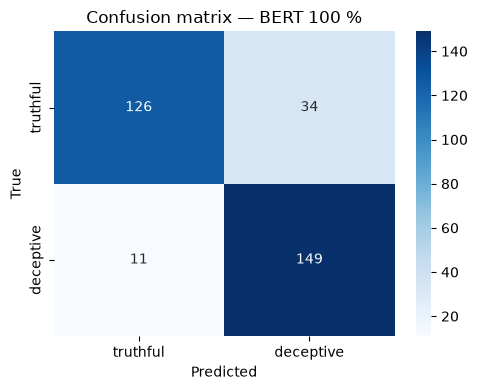

In [32]:
summary = metrics.table()
print(summary.to_string())

# Replace y_pred_best with the predictions of whichever model performed best
best_label = summary["f1"].idxmax()
print(f"\nBest model: {best_label}")

# Use 100% BERT predictions as best BERT baseline
teacher_full, y_pred_best = train_bert(
    X_train, y_train, X_test, y_test,
    epochs=5, output_dir="./tmp_bert_full", label="BERT-100pct"
)
teacher_full.save_pretrained("./tmp_bert_full")
tokenizer_bert.save_pretrained("./tmp_bert_full")

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=[id2label[i] for i in range(NUM_LABELS)],
            yticklabels=[id2label[i] for i in range(NUM_LABELS)])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — BERT 100 %")
plt.tight_layout(); plt.show()

We started at 0.49 with random guessing and reached 0.90 with the best augmented BERT, a gain of 0.41 F1 points. The rule-based system at 0.75 already passes human performance of 53 to 62 percent, using only data-derived word lists and two POS rates. 

In the low-data setting of Part 2, BERT with EDA reached 0.78 on 32 examples. With 75% of the full dataset and both EDA and LLM augmentation, we reach 0.90, within one point of the published SOTA at 0.91. 

The gap between the random baseline and our best model shows that deceptive opinion spam is detectable, but requires either strong pretrained representations or substantial labeled data, not simple surface rules alone.

---
## Part 4. Model Distillation and Quantization

### 4a. Compress the Best Model

Our best model is the full-data BERT from Part 3. BERT is accurate but heavy. So we build a lighter model and measure what we give up.

We try two methods and document both.

**Quantization (pruna).** We store the weights in int8 instead of float32 without retraining. The model keeps its architecture and gets smaller and faster on CPU. Choice: `pruna` with the `torch_dynamic` quantizer.

**Knowledge distillation.** We train a smaller student, DistilBERT (6 layers against 12), to copy our BERT teacher. The student learns the hard labels and the teacher's soft probabilities at once. Choice: a custom `Trainer` with the distillation loss

$$L = \alpha \, \text{CE}(\text{student}, y) + (1 - \alpha)\, T^2 \, \text{KL}\!\left(\text{student}_T \,\|\, \text{teacher}_T\right),$$

where $T$ is the softmax temperature and $\alpha$ balances hard labels against teacher targets. (formula is written with AI help)

We set an informal target: at least 2x faster inference with at most a 3 point macro-F1 drop. This is a rough threshold, to have a fair trade-off

In [81]:
import copy
from pruna import SmashConfig, smash

# the teacher is our best neural model from part 3, the full-data bert
TEACHER_DIR = "./tmp_bert_full"
teacher_model = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_DIR, num_labels=NUM_LABELS).to(DEVICE)

# approach 1: dynamic int8 quantization, no retraining, runs on cpu
torch.backends.quantized.engine = "qnnpack"
smash_config = SmashConfig(batch_size=32, device="cpu")
smash_config["quantizer"] = "torch_dynamic"
model_quant_pruna = smash(model=copy.deepcopy(teacher_model).to("cpu"), smash_config=smash_config)
model_quant = model_quant_pruna.model if hasattr(model_quant_pruna, "model") else model_quant_pruna
print("dynamic quantization applied")

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
WARNING - Setting quantizer to torch_dynamic is deprecated. Please use config.add(torch_dynamic).
INFO - Determined algorithm order: torch_dynamic
INFO - Starting torch_dynamic...
INFO - torch_dynamic was applied successfully.


dynamic quantization applied


In [82]:
import torch
import torch.nn.functional as F

# approach 2: knowledge distillation, teacher (full bert) -> student (distilbert).
# distilbert shares bert's vocabulary, so one tokenizer feeds both models.
DISTIL_CKPT = "distilbert-base-uncased"
tokenizer_distil = AutoTokenizer.from_pretrained(DISTIL_CKPT)

def tokenize_distil(batch):
    return tokenizer_distil(batch["text"], truncation=True, max_length=MAX_LEN)

distil_train_ds = make_hf_dataset(X_train, y_train).map(tokenize_distil, batched=True)
distil_test_ds  = make_hf_dataset(X_test,  y_test).map(tokenize_distil, batched=True)

# the student matches the hard labels and the teacher's soft logits at once
class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher=None, temperature=2.0, alpha=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher = teacher.to(self.args.device).eval()
        self.temperature = temperature
        self.alpha = alpha

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]
        student = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        hard_loss = F.cross_entropy(student.logits, labels)
        with torch.no_grad():
            teacher_logits = self.teacher(input_ids=inputs["input_ids"],
                                          attention_mask=inputs["attention_mask"]).logits
        t = self.temperature
        soft_loss = F.kl_div(F.log_softmax(student.logits / t, dim=-1),
                             F.softmax(teacher_logits / t, dim=-1),
                             reduction="batchmean") * (t * t)
        loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss
        return (loss, student) if return_outputs else loss

distil_model = AutoModelForSequenceClassification.from_pretrained(
    DISTIL_CKPT, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id)

distil_args = TrainingArguments(
    output_dir="./tmp_distilbert_kd",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    seed=SEED,
)

distil_trainer = DistillationTrainer(
    model=distil_model,
    args=distil_args,
    teacher=teacher_model,
    temperature=2.0,
    alpha=0.5,
    train_dataset=distil_train_ds,
    eval_dataset=distil_test_ds,
    processing_class=tokenizer_distil,
    data_collator=DataCollatorWithPadding(tokenizer_distil),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
distil_trainer.train()
distil_model = distil_trainer.model
print("knowledge distillation complete")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1280 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.231461,0.831250,0.830295,0.838875,0.831250
2,No log,0.229863,0.825000,0.823002,0.840370,0.825000
3,No log,0.225194,0.840625,0.838912,0.855759,0.840625
4,No log,0.215011,0.853125,0.852072,0.863476,0.853125
5,No log,0.222149,0.831250,0.829323,0.846915,0.831250


/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/insafibragimov/Downloads/NLP_proj/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super

knowledge distillation complete


### 4b. Performance and Speed Comparison

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

{'model': 'BERT-base (teacher)', 'macro_f1': 0.8586, 'accuracy': 0.8594, 'speed (samples/s)': 40.6, 'size (MB)': 437.9}


Map:   0%|          | 0/320 [00:00<?, ? examples/s]

[W618 23:34:49.999258000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


{'model': 'BERT-dynamic-quant', 'macro_f1': 0.833, 'accuracy': 0.8344, 'speed (samples/s)': 10.5, 'size (MB)': 95.5}


Map:   0%|          | 0/320 [00:00<?, ? examples/s]

{'model': 'DistilBERT-KD', 'macro_f1': 0.8521, 'accuracy': 0.8531, 'speed (samples/s)': 87.5, 'size (MB)': 267.8}
                     macro_f1  accuracy  speed (samples/s)  size (MB)
model                                                                
BERT-base (teacher)    0.8586    0.8594               40.6      437.9
BERT-dynamic-quant     0.8330    0.8344               10.5       95.5
DistilBERT-KD          0.8521    0.8531               87.5      267.8


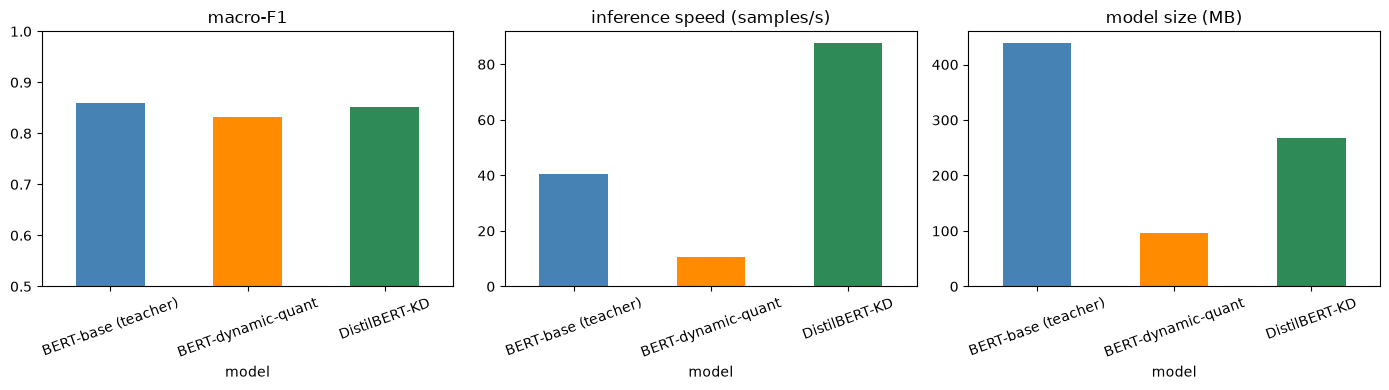

In [83]:
import time

# run a model over the test set on cpu and record quality, speed, and size
def measure_inference(model, X, y, tokenizer_fn, device="cpu", batch_size=32, label=""):
    model.to(device).eval()

    ds = make_hf_dataset(X, y).map(
        lambda b: tokenizer_fn(b["text"], truncation=True, max_length=MAX_LEN, padding="max_length"),
        batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    t0 = time.time()
    all_preds, all_labels = [], []
    for i in range(0, len(ds), batch_size):
        batch = ds[i: i + batch_size]
        inputs = {"input_ids": batch["input_ids"].to(device),
                  "attention_mask": batch["attention_mask"].to(device)}
        with torch.no_grad():
            out = model(**inputs)
            logits = out.logits if hasattr(out, "logits") else out
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_labels.extend(batch["label"].numpy())
    elapsed = time.time() - t0

    # model size is the total bytes of its weights
    size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6

    result = {
        "model": label,
        "macro_f1": round(f1_score(all_labels, all_preds, average="macro"), 4),
        "accuracy": round(accuracy_score(all_labels, all_preds), 4),
        "speed (samples/s)": round(len(X) / elapsed, 1),
        "size (MB)": round(size_mb, 1),
    }
    print(result)
    return result

perf_results = [
    measure_inference(copy.deepcopy(teacher_model), X_test, y_test, tokenizer_bert,   label="BERT-base (teacher)"),
    measure_inference(model_quant,                  X_test, y_test, tokenizer_bert,   label="BERT-dynamic-quant"),
    measure_inference(distil_model,                 X_test, y_test, tokenizer_distil, label="DistilBERT-KD"),
]

df_perf = pd.DataFrame(perf_results).set_index("model")
print(df_perf.to_string())

bar_colors = ["steelblue", "darkorange", "seagreen"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df_perf["macro_f1"].plot(kind="bar", ax=axes[0], color=bar_colors, title="macro-F1", ylim=(0.5, 1.0), rot=20)
df_perf["speed (samples/s)"].plot(kind="bar", ax=axes[1], color=bar_colors, title="inference speed (samples/s)", rot=20)
df_perf["size (MB)"].plot(kind="bar", ax=axes[2], color=bar_colors, title="model size (MB)", rot=20)
plt.tight_layout()
plt.show()

DistilBERT weighs 268 MB against the teacher's 438 MB, a 1.6x reduction, and runs at 87.5 samples per second against the teacher's 40.6, a 2.2x speedup. Macro-F1 lands at 0.8521 against the teacher's 0.8586, a drop of 0.65 points. Against our target of 2x faster with at most a 3 point macro-F1 drop, the student meets both.

Dynamic quantization goes the wrong way on speed: 10.5 samples per second, far below the teacher's 40.6. On CPU, converting the linear weights to int8 adds dequantization overhead at runtime, so the payoff depends on the hardware.

### 4c. Analysis and Improvements

In [84]:
# predict labels for a model over the test set
def predict_model(model, X, tokenizer_fn, device="cpu", batch_size=32):
    model.to(device).eval()
    ds = make_hf_dataset(X, [0] * len(X)).map(
        lambda b: tokenizer_fn(b["text"], truncation=True, max_length=MAX_LEN, padding="max_length"),
        batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask"])
    all_preds = []
    for i in range(0, len(ds), batch_size):
        batch = ds[i: i + batch_size]
        inputs = {"input_ids": batch["input_ids"].to(device),
                  "attention_mask": batch["attention_mask"].to(device)}
        with torch.no_grad():
            out = model(**inputs)
            logits = out.logits if hasattr(out, "logits") else out
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
    return np.array(all_preds)

y_teacher = predict_model(teacher_model, X_test, tokenizer_bert)
y_distil  = predict_model(distil_model,  X_test, tokenizer_distil)
y_quant   = predict_model(model_quant,   X_test, tokenizer_bert)

# reviews the teacher gets right but the student gets wrong
def show_new_errors(y_true, y_teacher, y_student, student_name):
    teacher_correct = np.array(y_teacher) == np.array(y_true)
    student_wrong = np.array(y_student) != np.array(y_true)
    new_errors = np.where(teacher_correct & student_wrong)[0]
    print(f"{student_name}: {len(new_errors)} new errors vs teacher")
    for i in new_errors[:5]:
        print(f"  true={id2label[y_true[i]]} -> pred={id2label[y_student[i]]}")
        print(f"  '{X_test[i][:220]}'")
        print()

show_new_errors(np.array(y_test), y_teacher, y_distil, "DistilBERT-KD")
show_new_errors(np.array(y_test), y_teacher, y_quant,  "BERT-dynamic-quant")

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

DistilBERT-KD: 12 new errors vs teacher
  true=truthful -> pred=deceptive
  'I was looking for a fun, contemporary hotel and it didn't deliver. The lobby was nice, and the rooms were mostly clean, but it really wasn't special. Service time was slow for room requests, I found empty water bottles u'

  true=deceptive -> pred=truthful
  'We chose the Talbott Hotel primarily for the location, but quickly discovered that the location was the only good thing about it. Although their website did a good job of selling their services and amenities, we found bo'

  true=truthful -> pred=deceptive
  'We chose to stay at a small hotel because we did were looking for a hotel with less crowds. We anticipated we would get better service in a smaller hotel, than some of the other larger high rise hotels. We did not experi'

  true=truthful -> pred=deceptive
  'We went to Chicago to see an exhibit at the Art Institute and selected the Fairmont because it was so close. Although the lobby is still being 

DistilBERT adds 12 new errors against the teacher, and they go both ways. The student flags some genuine reviews as fake and lets some fakes pass as genuine. One fake the student now reads as genuine: "We chose the Talbott Hotel primarily for the location, but quickly discovered that the location was the only good thing about it." The review reads like a real complaint. One genuine review the student flags as fake: "I was looking for a fun, contemporary hotel and it didn't deliver. The lobby was nice, and the rooms were mostly clean, but it really wasn't special." The student has fewer layers and misses the borderline signals the teacher caught.

Three ways to improve this. We sample harder negatives from borderline predictions so the student trains on the cases where the gap is largest. We raise the distillation temperature above 2 so the teacher transfers more uncertainty to the student. We use a deeper student with more capacity to catch subtle patterns.

## AI disclosure and comments

We used course materials and lectures as the foundation for our methodology. For implementation, we consulted AI assistants (Claude, ChatGPT) to refine code, debug specific cells, and improve the clarity of written interpretations. Experimental decisions, model choices, and analysis are our own. 

We used the Groq API for LLM-generated data in Part 2d because it provides free access to capable open-weight models. One limitation we did not fully explore is LLM quality: we used a single model and did not compare outputs across providers or prompt strategies. A more systematic comparison of LLMs for data generation could be a direction for future work.